# Phase 2 Vision Final Evaluation

This notebook compares the pretrained torchxrayvision baseline against the fine-tuned DenseNet-121 model.

## Main Question

Did fine-tuning on the Phase 1 dataset beat the domain-pretrained baseline?

The honest answer matters more than forcing a win.

In [19]:
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import roc_auc_score, roc_curve

PROJECT_ROOT = Path('..').resolve()
OUT_DIR = PROJECT_ROOT / 'outputs' / 'vision'

BASELINE_METRICS_PATH = OUT_DIR / 'baseline_test_metrics.csv'
FINETUNED_METRICS_PATH = OUT_DIR / 'finetuned_test_metrics.csv'
BASELINE_PREDS_PATH = OUT_DIR / 'baseline_test_predictions.csv'
FINETUNED_PREDS_PATH = OUT_DIR / 'finetuned_test_predictions.csv'

DISEASE_LABELS = [
    'Cardiomegaly',
    'Atelectasis',
    'Consolidation / Pneumonia',
    'Pleural Effusion',
    'Edema',
    'Pneumothorax',
]

SUPPORTED_LABELS = [
    'Cardiomegaly',
    'Atelectasis',
    'Consolidation / Pneumonia',
    'Pleural Effusion',
]

def safe_name(label):
    return label.replace(' / ', '_').replace(' ', '_')

## Load Results

In [20]:
baseline_metrics = pd.read_csv(BASELINE_METRICS_PATH).assign(model='baseline')
finetuned_metrics = pd.read_csv(FINETUNED_METRICS_PATH).assign(model='fine-tuned')

baseline_preds = pd.read_csv(BASELINE_PREDS_PATH)
finetuned_preds = pd.read_csv(FINETUNED_PREDS_PATH)

baseline_preds.shape, finetuned_preds.shape

((550, 13), (550, 13))

Both prediction files are study-level, so each study counts once in the final test metrics.

In [21]:
baseline_preds['study_id'].nunique(), finetuned_preds['study_id'].nunique()

(550, 550)

## Combined Metrics Table

In [22]:
combined = pd.concat([baseline_metrics, finetuned_metrics], ignore_index=True)
combined = combined[['model', 'label', 'test_positive_studies', 'AUROC', 'AP', 'note']]
combined

,model,label,test_positive_studies,AUROC,AP,note
0,baseline,Cardiomegaly,44,0.896020,0.423935,NaN
1,baseline,Atelectasis,44,0.816475,0.305457,NaN
2,baseline,Consolidation / Pneumonia,28,0.895252,0.293925,NaN
3,baseline,Pleural Effusion,22,0.931129,0.705717,NaN
4,baseline,Edema,2,0.552920,0.168707,data-limited
5,baseline,Pneumothorax,3,0.329068,0.005797,data-limited
6,fine-tuned,Cardiomegaly,44,0.887576,0.421361,NaN
7,fine-tuned,Atelectasis,44,0.825862,0.407550,NaN
8,fine-tuned,Consolidation / Pneumonia,28,0.877531,0.212729,NaN
9,fine-tuned,Pleural Effusion,22,0.906078,0.530047,NaN


## Headline Macro-AUROC

The headline score uses only the 4 supported classes. Edema and Pneumothorax have too few positives to measure reliably.

In [23]:
headline = (
    combined[combined['label'].isin(SUPPORTED_LABELS)]
    .groupby('model', as_index=False)['AUROC']
    .mean()
    .rename(columns={'AUROC': 'macro_AUROC_supported_4'})
)

headline

,model,macro_AUROC_supported_4
0,baseline,0.884719
1,fine-tuned,0.874262


In [24]:
ap_comparison = (
    combined[combined['label'].isin(SUPPORTED_LABELS)]
    .pivot(index='label', columns='model', values='AP')
    .reset_index()
)
ap_comparison['fine_tuned_minus_baseline_AP'] = ap_comparison['fine-tuned'] - ap_comparison['baseline']
ap_comparison

model,label,baseline,fine-tuned,fine_tuned_minus_baseline_AP
0,Atelectasis,0.305457,0.407550,0.102093
1,Cardiomegaly,0.423935,0.421361,-0.002574
2,Consolidation / Pneumonia,0.293925,0.212729,-0.081196
3,Pleural Effusion,0.705717,0.530047,-0.175669


## ROC Curves

Baseline and fine-tuned ROC curves are overlaid for the 4 supported classes.

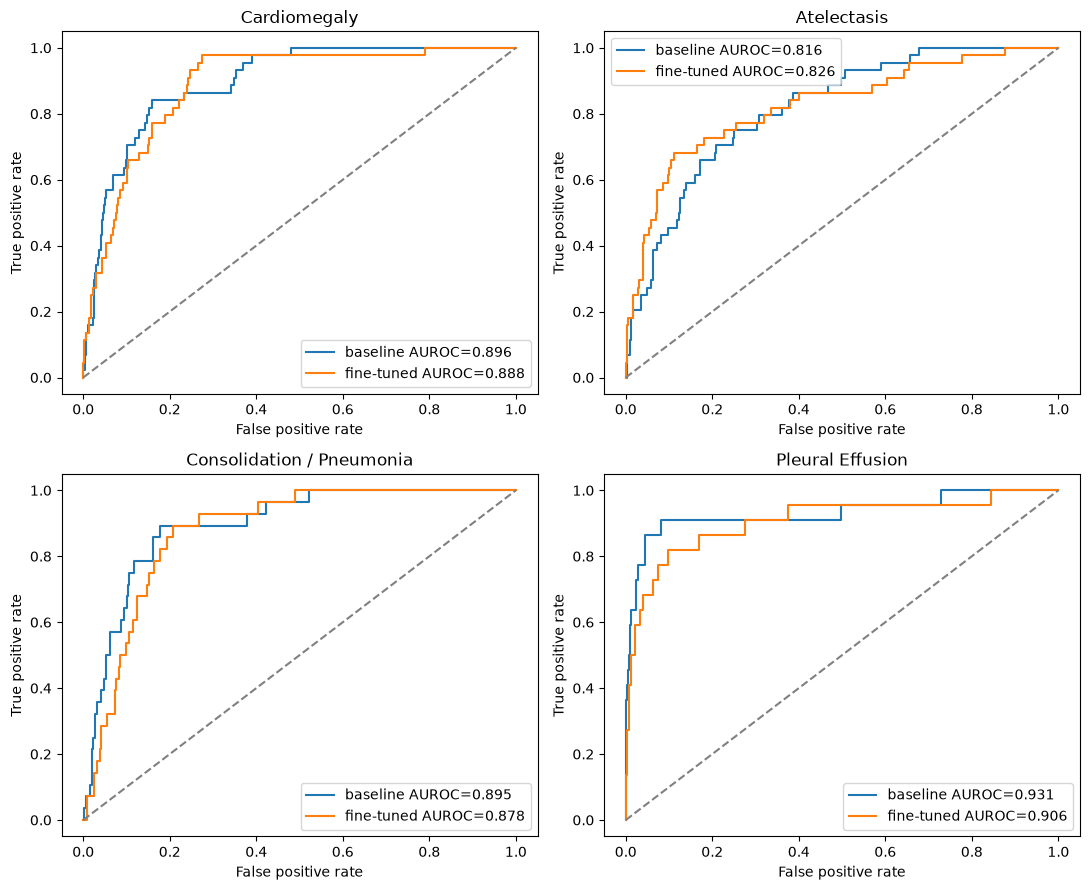

In [25]:
fig, axes = plt.subplots(2, 2, figsize=(11, 9))
axes = axes.flatten()

for ax, label in zip(axes, SUPPORTED_LABELS):
    name = safe_name(label)
    true_col = f'true_{name}'
    prob_col = f'prob_{name}'

    y_true = baseline_preds[true_col].astype(int)

    base_prob = baseline_preds[prob_col].astype(float)
    base_fpr, base_tpr, _ = roc_curve(y_true, base_prob)
    base_auc = roc_auc_score(y_true, base_prob)

    fine_prob = finetuned_preds[prob_col].astype(float)
    fine_fpr, fine_tpr, _ = roc_curve(y_true, fine_prob)
    fine_auc = roc_auc_score(y_true, fine_prob)

    ax.plot(base_fpr, base_tpr, label=f'baseline AUROC={base_auc:.3f}')
    ax.plot(fine_fpr, fine_tpr, label=f'fine-tuned AUROC={fine_auc:.3f}')
    ax.plot([0, 1], [0, 1], linestyle='--', color='gray')
    ax.set_title(label)
    ax.set_xlabel('False positive rate')
    ax.set_ylabel('True positive rate')
    ax.legend()

plt.tight_layout()
plt.show()

## Example Predictions

This section finds cases where the baseline and fine-tuned model disagree. These are useful for understanding model behaviour.

In [26]:
def prediction_view(label):
    name = safe_name(label)
    true_col = f'true_{name}'
    prob_col = f'prob_{name}'

    view = baseline_preds[['study_id', true_col, prob_col]].rename(
        columns={true_col: 'true', prob_col: 'baseline_prob'}
    )
    view = view.merge(
        finetuned_preds[['study_id', prob_col]].rename(columns={prob_col: 'finetuned_prob'}),
        on='study_id',
        how='inner',
    )
    view['abs_gap'] = (view['finetuned_prob'] - view['baseline_prob']).abs()
    view['label'] = label
    return view.sort_values('abs_gap', ascending=False)


disagreements = pd.concat([prediction_view(label).head(5) for label in SUPPORTED_LABELS], ignore_index=True)
disagreements.sort_values('abs_gap', ascending=False).head(10)

,study_id,true,baseline_prob,finetuned_prob,abs_gap,label
0,257,0.0,0.092054,0.887186,0.795132,Cardiomegaly
1,3222,0.0,0.073600,0.861962,0.788362,Cardiomegaly
5,1021,1.0,0.085470,0.872677,0.787207,Atelectasis
2,1174,0.0,0.153262,0.923114,0.769852,Cardiomegaly
3,1196,0.0,0.104449,0.847081,0.742632,Cardiomegaly
15,2728,0.0,0.093998,0.778869,0.684871,Pleural Effusion
4,2862,0.0,0.066972,0.745702,0.678730,Cardiomegaly
6,869,0.0,0.145979,0.805779,0.659799,Atelectasis
10,1021,0.0,0.125458,0.772558,0.647099,Consolidation / Pneumonia
11,3951,0.0,0.755264,0.162544,0.592721,Consolidation / Pneumonia


Pick one of these rows as a failure or disagreement case, then read its report text in the Phase 1 manifest if you want to explain it in words.

In [27]:
MANIFEST_PATH = PROJECT_ROOT / 'data' / 'processed' / 'manifest.parquet'
manifest = pd.read_parquet(MANIFEST_PATH)

example = disagreements.sort_values('abs_gap', ascending=False).iloc[0]
example_study_id = str(example['study_id'])

example_rows = manifest[manifest['study_id'].astype(str) == example_study_id]
print('study_id:', example_study_id)
print('label checked:', example['label'])
print('true:', example['true'])
print('baseline prob:', round(example['baseline_prob'], 3))
print('fine-tuned prob:', round(example['finetuned_prob'], 3))
print('manifest labels:', example_rows['labels'].iloc[0])
print('report text:')
print(example_rows['report_text'].iloc[0])

study_id: 257
label checked: Cardiomegaly
true: 0.0
baseline prob: 0.092
fine-tuned prob: 0.887
manifest labels: ['Other']
report text:
Midline sternotomy identified. Heart size and cardiomediastinal silhouette are grossly normal. Airspace opacity in posterior segment on the lateral view. Osseous structures are grossly intact.


## Honest Conclusion

The domain-pretrained torchxrayvision baseline slightly outperformed the fine-tuned DenseNet overall on the 4 supported classes. This is expected because the baseline was trained on far larger chest X-ray datasets, while this fine-tune used 2,653 training images.

The fine-tuned model did improve Atelectasis AP, which shows that fine-tuning learned something useful for at least one class. But the baseline remained stronger overall, especially for Pleural Effusion and Consolidation / Pneumonia.

Edema and Pneumothorax remain data-limited, with only 2 and 3 positive test studies, so their metrics are shown with counts but should not be treated as reliable headline results.